# Importing the data file

In [23]:
import pandas as pd

news_path = "../data/raw/newsData/raw_analyst_ratings.csv"

df_news = pd.read_csv(news_path)

df_news.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


# Descriptive Statistics

### Counting articles per publisher

In [24]:
df_news["headline_length"] = df_news["headline"].str.len()
df_news.head()

,Unnamed: 0,headline,url,publisher,date,stock,headline_length
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A,39
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A,42
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A,29
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A,44
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A,87


In [25]:
df_news["headline_length"].describe()

count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64

### Visualization of the headline length distribution

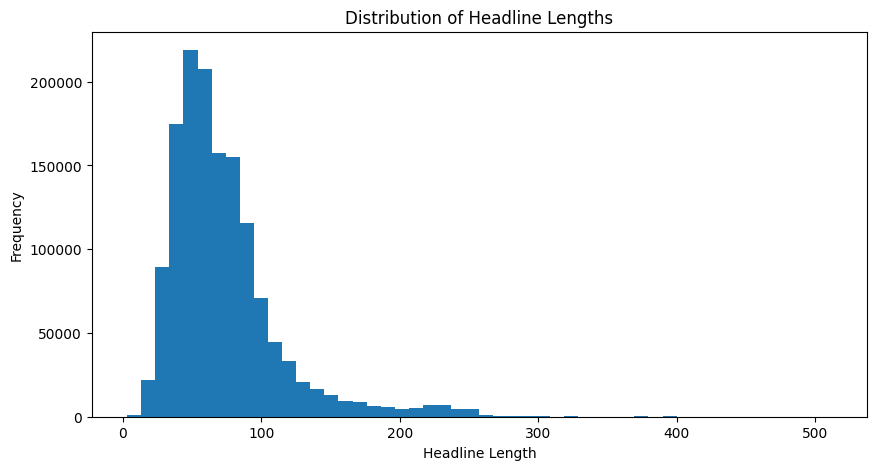

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(df_news["headline_length"], bins=50)
plt.title("Distribution of Headline Lengths")
plt.xlabel("Headline Length")
plt.ylabel("Frequency")
plt.show()

The histogram shows that most headlines are less than 100 characters in length, with a few having upto 400 characters.

### Analyzing articles per publisher

In [27]:
publisher_counts = df_news["publisher"].value_counts()
publisher_counts.head(10)

publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64

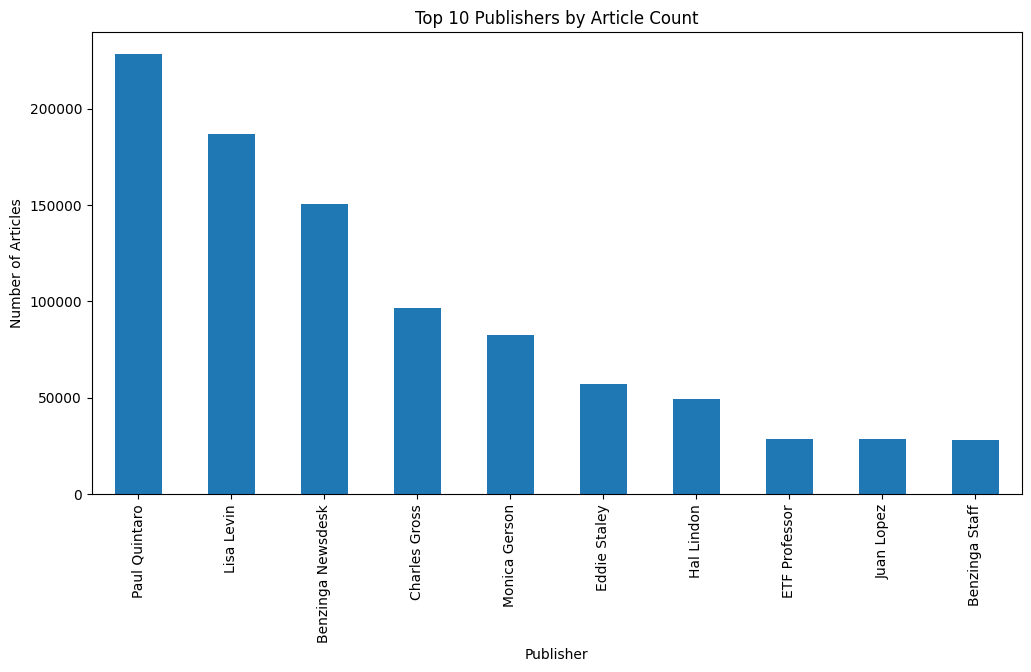

In [28]:
top_publishers = publisher_counts.head(10)

plt.figure(figsize=(12,6))
top_publishers.plot(kind="bar")

plt.title("Top 10 Publishers by Article Count")
plt.xlabel("Publisher")
plt.ylabel("Number of Articles")

plt.show()

### Analyzing date trends

In [32]:
df_news["date"] = pd.to_datetime(df_news["date"], format="mixed", utc=True)
df_news["date_only"] = df_news["date"].dt.date
df_news["date"].isna().sum()

np.int64(0)

There are no invalid dates, so no cleaning is required. Although, some rows do not contain a timezone so pandas threw an error. To solve this, all dates were converted to utc time zone.

### Counting frequency of news publication by date

In [ ]:
daily_news_count = df_news.groupby("date_only").size()
daily_news_count.head()

date_only
2009-02-14    1
2009-04-27    2
2009-04-29    1
2009-05-22    1
2009-05-27    6
dtype: int64

In [30]:
daily_news_count.sort_values(ascending=False).head(10)

date_only
2020-03-12    2739
2020-02-28    1620
2020-03-19    1595
2020-02-27    1567
2020-03-06    1428
2020-05-07    1398
2020-03-23    1391
2020-04-29    1389
2020-03-11    1384
2020-04-30    1327
dtype: int64

The data shows that there was a significant peak in news publication in 2020-03-12 (March 12, 2020). The number of publications is almost twice as much as that of most days. This could be attributed to the massive acceleration of the COVID-19 pandemic, resulting in a global stock market crash.

### Visualizing frequency of news publications by date

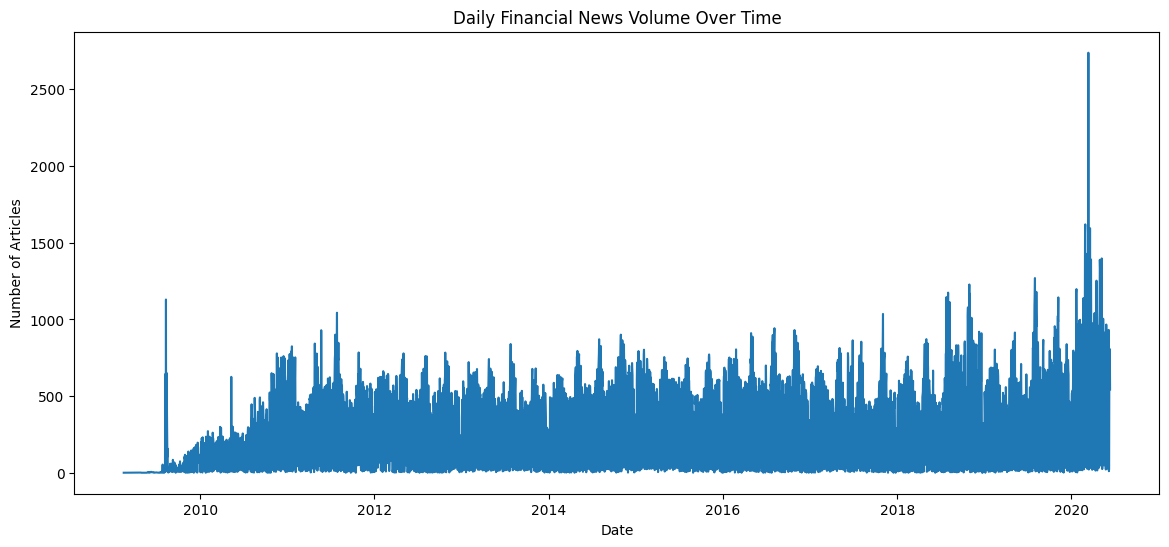

In [ ]:
plt.figure(figsize=(14,6))

daily_news_count.plot()

plt.title("Daily Financial News Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Articles")

plt.show()

# Text analysis

### Cleaning the headlines (pre-processing)

In [34]:
import re

df_news["clean_headline"] = (
    df_news["headline"]
    .astype(str)
    .str.lower()
    .apply(lambda x: re.sub(r"[^\w\s]", "", x))
)

df_news[["headline", "clean_headline"]].head()

,headline,clean_headline
0,Stocks That Hit 52-Week Highs On Friday,stocks that hit 52week highs on friday
1,Stocks That Hit 52-Week Highs On Wednesday,stocks that hit 52week highs on wednesday
2,71 Biggest Movers From Friday,71 biggest movers from friday
3,46 Stocks Moving In Friday's Mid-Day Session,46 stocks moving in fridays midday session
4,B of A Securities Maintains Neutral on Agilent...,b of a securities maintains neutral on agilent...


### Identifying common keywords and phrases in headlines

In [ ]:
from collections import Counter

all_words = " ".join(df_news["clean_headline"]).split()

word_counts = Counter(all_words)

word_counts.most_common(20)


[('to', 402875),
 ('of', 269807),
 ('on', 245071),
 ('for', 238895),
 ('in', 220556),
 ('the', 212758),
 ('vs', 162061),
 ('stocks', 161868),
 ('est', 140578),
 ('eps', 128910),
 ('from', 120708),
 ('shares', 114182),
 ('and', 113434),
 ('reports', 108705),
 ('update', 91680),
 ('market', 90879),
 ('earnings', 87185),
 ('with', 84203),
 ('sales', 79524),
 ('top', 78648)]

### Removing stop words that pollute the result

In [36]:
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

filtered_words = [
    word for word in all_words
    if word not in stop_words
]

filtered_counts = Counter(filtered_words)
filtered_counts.most_common(20)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\megde\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


[('vs', 162061),
 ('stocks', 161868),
 ('est', 140578),
 ('eps', 128910),
 ('shares', 114182),
 ('reports', 108705),
 ('update', 91680),
 ('market', 90879),
 ('earnings', 87185),
 ('sales', 79524),
 ('top', 78648),
 ('pt', 73043),
 ('announces', 66528),
 ('price', 64231),
 ('buy', 64059),
 ('downgrades', 61942),
 ('trading', 61156),
 ('benzingas', 57985),
 ('raises', 57798),
 ('upgrades', 56804)]

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vec = CountVectorizer(stop_words="english", max_features=20)
X = vec.fit_transform(df_news["headline"])

word_counts = pd.DataFrame({
    "word": vec.get_feature_names_out(),
    "count": X.toarray().sum(axis=0)
}).sort_values("count", ascending=False)

word_counts